In [ ]:
# Pandas and NumPy are for handling data
# sklearn has tools for splitting data and building models
# matplotlib is for plotting graphs
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

In [ ]:
#read in dataset
import kagglehub
qsar_biodegradation_path = kagglehub.dataset_download("muhammetvarl/qsarbiodegradation")
print("Dataset successfully loaded.")

#create dataframe from path
biodeg = pd.read_csv(qsar_biodegradation_path+'/qsar-biodeg.csv')

100%|██████████| 48.4k/48.4k [00:00<00:00, 12.3MB/s]

Extracting files...
Dataset successfully loaded.


In [ ]:
X = biodeg.iloc[:,:-1].values
X = X[:,[2, 4, 5, 6, 10, 16, 21, 23, 26, 31, 36, 37]]

y = biodeg.iloc[:,-1].values

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (1055, 12)
Target shape: (1055,)


In [ ]:
# Split data into training and test sets
# 80% of data will be used to train the model, 20% to test it
# stratify=y makes sure both classes are represented equally in train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (844, 12)
X_test shape: (211, 12)
y_train shape: (844,)
y_test shape: (211,)


In [ ]:
# Train a K-Nearest Neighbors (KNN) model
# Using k=5 neighbors and weighting by distance so closer points matter more
knn = KNeighborsClassifier(n_neighbors=5, weights='distance')

# Fit the model on the training data
knn.fit(X_train, y_train)

KNeighborsClassifier(weights='distance')

In [ ]:
# Evaluate the model
# Make predictions on the test set
y_pred = knn.predict(X_test)

# Check overall accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Show confusion matrix to see correct vs wrong predictions
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Detailed report with precision, recall, and f1-score for each class
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8388625592417062

Confusion Matrix:
 [[124  16]
 [ 18  53]]

Classification Report:
               precision    recall  f1-score   support

           1       0.87      0.89      0.88       140
           2       0.77      0.75      0.76        71

    accuracy                           0.84       211
   macro avg       0.82      0.82      0.82       211
weighted avg       0.84      0.84      0.84       211



In [ ]:
# Import necessary modules for cross-validation
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Set up stratified 5-fold cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation and get accuracy scores
cv_scores = cross_val_score(knn, X, y, cv=skf, scoring='accuracy')

print("Cross-validation scores:", cv_scores)
print("Mean CV accuracy: %0.2f (+/- %0.2f)" % (cv_scores.mean(), cv_scores.std() * 2))

Cross-validation scores: [0.8436019  0.8436019  0.81042654 0.77251185 0.81990521]
Mean CV accuracy: 0.82 (+/- 0.05)


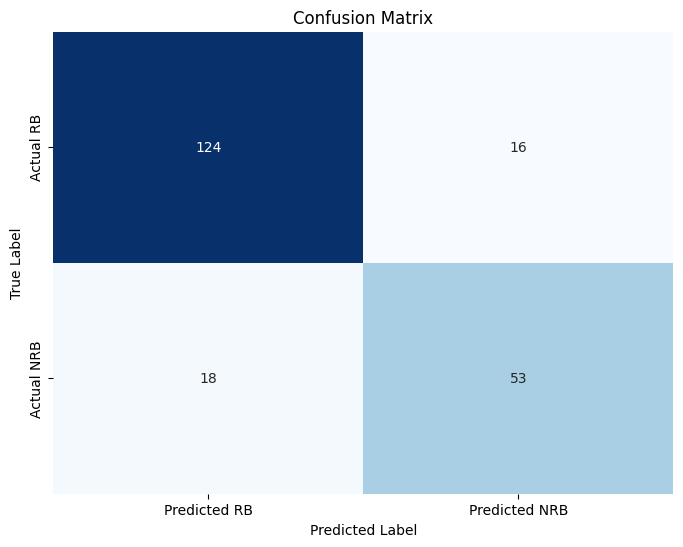

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Get the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plotting the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted RB', 'Predicted NRB'],
            yticklabels=['Actual RB', 'Actual NRB'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
from sklearn.svm import SVC

svm_model = SVC(kernel='rbf')
svm_model.fit(X_train, y_train)

SVC()

In [ ]:
y_pred_svm = svm_model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.8436018957345972

Confusion Matrix:
 [[128  12]
 [ 21  50]]

Classification Report:
               precision    recall  f1-score   support

           1       0.86      0.91      0.89       140
           2       0.81      0.70      0.75        71

    accuracy                           0.84       211
   macro avg       0.83      0.81      0.82       211
weighted avg       0.84      0.84      0.84       211



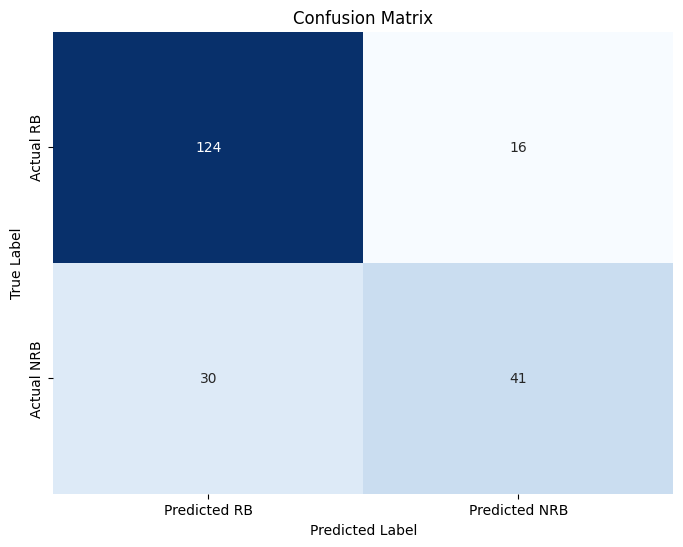

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Get the confusion matrix
cm = confusion_matrix(y_test, y_pred_svm)

# Plotting the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted RB', 'Predicted NRB'],
            yticklabels=['Actual RB', 'Actual NRB'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
# Import necessary modules for cross-validation
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Set up stratified 5-fold cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation and get accuracy scores
cv_scores = cross_val_score(svm_model, X, y, cv=skf, scoring='accuracy')

print("Cross-validation scores:", cv_scores)
print("Mean CV accuracy: %0.2f (+/- %0.2f)" % (cv_scores.mean(), cv_scores.std() * 2))

Cross-validation scores: [0.82938389 0.8056872  0.81042654 0.78199052 0.82938389]
Mean CV accuracy: 0.81 (+/- 0.04)
